In [1]:
# Step 1: Import Libraries and Load the Model
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import load_model

In [2]:
# Load the IMDB dataset word index
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

In [3]:
# Load the pre-trained model with ReLU activation
model = load_model('model-files/simple_rnn_imdb.h5')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,027 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [4]:
## this is an imp feature sometimes we just directly save the weigths of the model and then load it to a new model architecture and use it for prediction or further training
model.get_weights()

[array([[ 8.1326567e-02, -2.0928148e-03, -1.1558588e-02, ...,
         -1.4414394e-04, -2.3834949e-02,  4.9069896e-02],
        [ 3.1078229e-02,  3.7871338e-02,  3.7471194e-02, ...,
         -2.1354513e-02, -4.6925973e-03,  9.9997851e-04],
        [ 5.6570888e-02,  1.3459723e-02,  2.8731089e-02, ...,
         -5.1837411e-02, -4.5441858e-02, -2.1550365e-02],
        ...,
        [-4.3139372e-02,  7.2318189e-02,  3.9710324e-02, ...,
         -6.5704934e-02, -5.4032512e-02, -2.2473194e-02],
        [-3.1941175e-02, -4.3998291e-03, -6.9057532e-03, ...,
          5.0533116e-03, -3.8773496e-02,  2.3118476e-03],
        [-2.1811312e-01,  2.4413726e-01,  2.3139066e-01, ...,
         -1.6427144e-01,  4.7035802e-02,  1.2199167e-01]], dtype=float32),
 array([[-0.04490904,  0.14829364, -0.12585382, ..., -0.03824696,
          0.10031332,  0.06484768],
        [-0.10499382, -0.07697512, -0.12057533, ...,  0.13227126,
          0.00104209,  0.04102889],
        [ 0.10804013, -0.02397083, -0.08794358

In [5]:
import re
# Function to decode reviews
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

# Function to preprocess user input
# def preprocess_text(text):

#     text = text.lower()

#     words = text.split()

#     encoded_review = [word_index.get(word, 2) + 3 for word in words]

#     print(words)
#     print(encoded_review)

#     padded_review = sequence.pad_sequences(
#         [encoded_review],
#         maxlen=500
#     )

#     return padded_review

def preprocess_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    encoded_review = []

    for word in words:

        if word in word_index and word_index[word] < 10000:
            encoded_review.append(word_index[word] + 3)

        else:
            encoded_review.append(2)

    padded_review = sequence.pad_sequences(
        [encoded_review],
        maxlen=500
    )

    return padded_review

In [6]:
### Prediction  function

def predict_sentiment(review):
    preprocessed_input=preprocess_text(review)

    prediction=model.predict(preprocessed_input)

    sentiment = 'Positive' if prediction[0][0] > 0.5 else 'Negative'
    
    return sentiment, prediction[0][0]

In [7]:
# Example review for prediction
example_review = "This movie was fantastic! The acting was great and the plot was thrilling."

sentiment,score=predict_sentiment(example_review)

print(f'Review: {example_review}')
print(f'Sentiment: {sentiment}')
print(f'Prediction Score: {score}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Review: This movie was fantastic! The acting was great and the plot was thrilling.
Sentiment: Positive
Prediction Score: 0.9830986857414246


In [8]:
example2 = "I like this movie it gives a lot of inspiration for a better life"

sentiment,score=predict_sentiment(example2)

print(f'Review: {example2}')
print(f'Sentiment: {sentiment}')
print(f'Prediction Score: {score}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Review: I like this movie it gives a lot of inspiration for a better life
Sentiment: Positive
Prediction Score: 0.9855879545211792


In [9]:
example3 = "This the worst movie of all time, I wasted my time watching it"

sentiment,score=predict_sentiment(example3)

print(f'Review: {example3}')
print(f'Sentiment: {sentiment}')
print(f'Prediction Score: {score}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Review: This the worst movie of all time, I wasted my time watching it
Sentiment: Positive
Prediction Score: 0.8638523817062378


In [10]:
test_reviews = [
    "I loved this movie. It was fantastic and inspiring.",
    
    "This movie was horrible and disgusting. I hated every minute of it.",
    
    "Absolutely terrible film. Waste of time.",
    
    "One of the best movies I have ever watched.",
    
    "Bad acting, boring story, and awful direction."
]

for review in test_reviews:

    sentiment, score = predict_sentiment(review)

    print(f"\nReview: {review}")
    print(f"Sentiment: {sentiment}")
    print(f"Score: {score}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Review: I loved this movie. It was fantastic and inspiring.
Sentiment: Positive
Score: 0.9897789359092712
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Review: This movie was horrible and disgusting. I hated every minute of it.
Sentiment: Positive
Score: 0.5945010185241699
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Review: Absolutely terrible film. Waste of time.
Sentiment: Positive
Score: 0.697982907295227
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Review: One of the best movies I have ever watched.
Sentiment: Positive
Score: 0.9888213872909546
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Review: Bad acting, boring story, and awful direction.
Sentiment: Negative
Score: 0.46732890605926514


### Limitations of Simple RNN

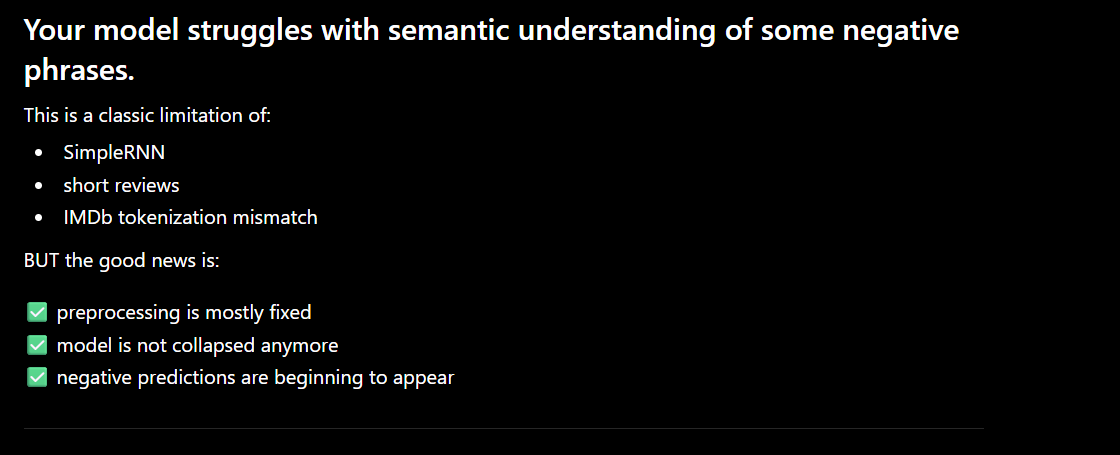

#### It is proposed to change the Simple RNN to LSTM and GRU and compare the results.